In [ ]:
!pip install plotly

Installing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Loading Dataset

In [ ]:
df = pd.read_csv('/content/MoviesOnStreamingPlatforms.csv')
df.head()

,Unnamed: 0,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type
0,0,1,The Irishman,2019,18+,98/100,1,0,0,0,0
1,1,2,Dangal,2016,7+,97/100,1,0,0,0,0
2,2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,0
3,3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,0
4,4,5,Roma,2018,18+,94/100,1,0,0,0,0


Understanding the dataset

In [ ]:
df.info()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9515 entries, 0 to 9514
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       9515 non-null   int64 
 1   ID               9515 non-null   int64 
 2   Title            9515 non-null   object
 3   Year             9515 non-null   int64 
 4   Age              5338 non-null   object
 5   Rotten Tomatoes  9508 non-null   object
 6   Netflix          9515 non-null   int64 
 7   Hulu             9515 non-null   int64 
 8   Prime Video      9515 non-null   int64 
 9   Disney+          9515 non-null   int64 
 10  Type             9515 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 817.8+ KB


Index(['Unnamed: 0', 'ID', 'Title', 'Year', 'Age', 'Rotten Tomatoes',
       'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'Type'],
      dtype='object')

# Data Cleaning

Removing Unwanted Columns

In [ ]:
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

Checking for missing values

In [ ]:
df.isnull().sum()

,0
ID,0
Title,0
Year,0
Age,0
Rotten Tomatoes,7
Netflix,0
Hulu,0
Prime Video,0
Disney+,0
Type,0


Filling Missing values

In [ ]:
df['Rotten Tomatoes'].fillna('0/100', inplace=True)

/tmp/ipykernel_3586/370799534.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rotten Tomatoes'].fillna('0/100', inplace=True)


Converting Rotten Tomatoes Ratings to Numeric

In [ ]:
df['Rotten Tomatoes'] = df['Rotten Tomatoes'].str.replace('/100', '')
df['Rotten Tomatoes'] = df['Rotten Tomatoes'].astype(int)

Checking Cleaned Data

In [ ]:
df.head()

,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type
0,1,The Irishman,2019,18+,98,1,0,0,0,0
1,2,Dangal,2016,7+,97,1,0,0,0,0
2,3,David Attenborough: A Life on Our Planet,2020,7+,95,1,0,0,0,0
3,4,Lagaan: Once Upon a Time in India,2001,7+,94,1,0,0,0,0
4,5,Roma,2018,18+,94,1,0,0,0,0


# EXPLORATORY DATA ANALYSIS (EDA)

Counting total Content on Each Platform

In [ ]:
platform_counts = {
    'Netflix': df['Netflix'].sum(),
    'Hulu': df['Hulu'].sum(),
    'Prime Video': df['Prime Video'].sum(),
    'Disney+': df['Disney+'].sum()
}

platform_counts

{'Netflix': np.int64(3695),
 'Hulu': np.int64(1047),
 'Prime Video': np.int64(4113),
 'Disney+': np.int64(922)}

Visualizing Platform Content

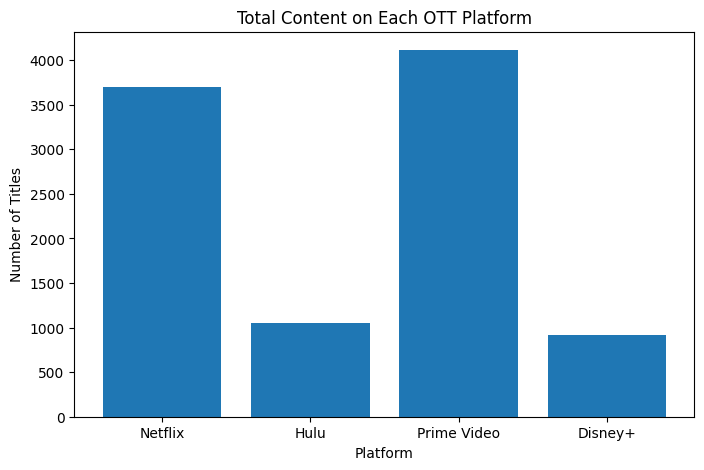

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(platform_counts.keys(), platform_counts.values())

plt.title('Total Content on Each OTT Platform')
plt.xlabel('Platform')
plt.ylabel('Number of Titles')

plt.show()

Analyzing Age Rating Distribution

In [ ]:
df['Age'].value_counts()

,count
Age,
Unknown,4177
18+,2276
7+,1090
13+,998
all,698
16+,276


Visualizing Age Ratings

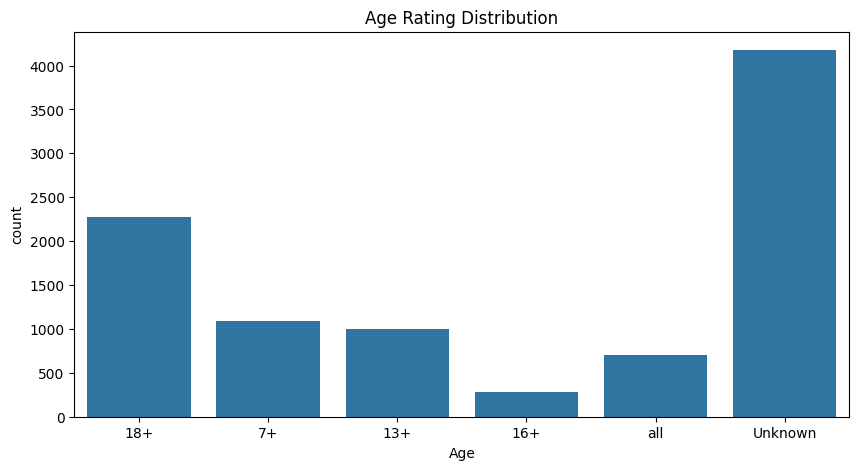

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(x='Age', data=df)

plt.title('Age Rating Distribution')

plt.show()

Analyzing Rotten Tomatoes Ratings Distribution

In [ ]:
df['Rotten Tomatoes'].describe()

,Rotten Tomatoes
count,9515.000000
mean,53.505623
std,13.272465
min,0.000000
25%,44.000000
50%,52.000000
75%,62.000000
max,98.000000


Visualizing Histogram of Ratings

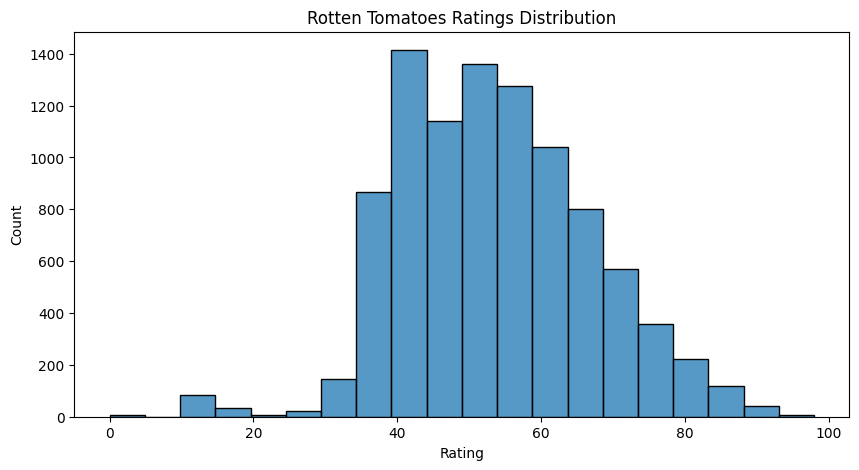

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df['Rotten Tomatoes'], bins=20)

plt.title('Rotten Tomatoes Ratings Distribution')

plt.xlabel('Rating')

plt.show()

Analyzing Content growth over years

In [ ]:
yearly_content = df['Year'].value_counts().sort_index()

yearly_content

,count
Year,
1914,1
1915,2
1916,1
1919,1
1920,2
...,...
2017,831
2018,945
2019,1014


Visualizing Content Growth by Line Chart

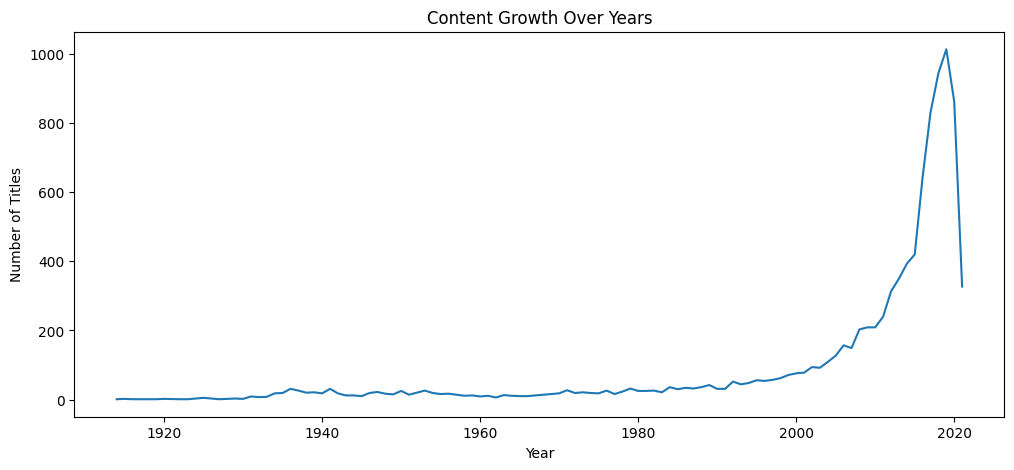

In [ ]:
plt.figure(figsize=(12,5))

yearly_content.plot()

plt.title('Content Growth Over Years')

plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.show()

**Movies vs TV Shows**

The "Type" column:

0 = Movie
1 = TV Show

Converting Type Values

In [ ]:
df['Type'] = df['Type'].replace({
    0: 'Movie',
    1: 'TV Show'
})

Counting Types

In [ ]:
df['Type'].value_counts()

,count
Type,
Movie,9515


Visualizing Via Pie Chart

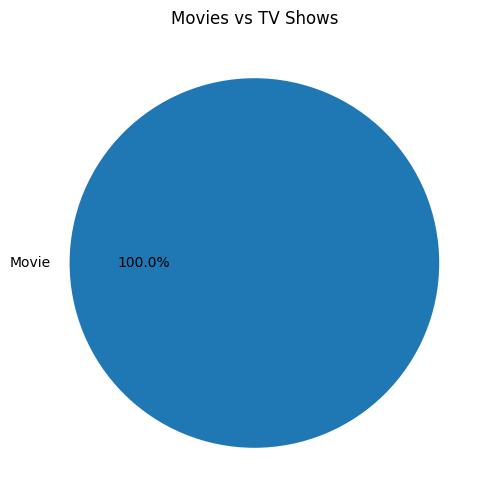

In [ ]:
plt.figure(figsize=(6,6))

df['Type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Movies vs TV Shows')

plt.ylabel('')

plt.show()

Analyzing average rating by Platform

In [ ]:
netflix_avg = df[df['Netflix'] == 1]['Rotten Tomatoes'].mean()

hulu_avg = df[df['Hulu'] == 1]['Rotten Tomatoes'].mean()

prime_avg = df[df['Prime Video'] == 1]['Rotten Tomatoes'].mean()

disney_avg = df[df['Disney+'] == 1]['Rotten Tomatoes'].mean()

Creating Comparison Dictionary

In [ ]:
avg_ratings = {
    'Netflix': netflix_avg,
    'Hulu': hulu_avg,
    'Prime Video': prime_avg,
    'Disney+': disney_avg
}

avg_ratings

{'Netflix': np.float64(54.344790257104194),
 'Hulu': np.float64(60.39732569245463),
 'Prime Video': np.float64(50.398735716022365),
 'Disney+': np.float64(58.31236442516269)}

Visualizing ratings

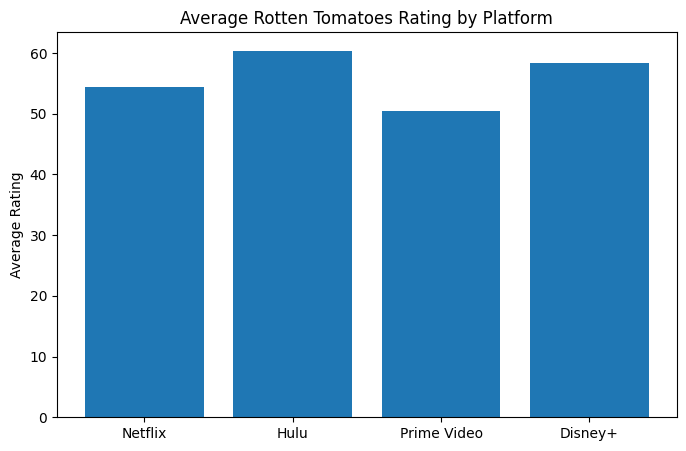

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(avg_ratings.keys(), avg_ratings.values())

plt.title('Average Rotten Tomatoes Rating by Platform')

plt.ylabel('Average Rating')

plt.show()

Multi Platform Availability

In [ ]:
df['Total_Platforms'] = (
    df['Netflix'] +
    df['Hulu'] +
    df['Prime Video'] +
    df['Disney+']
)

Checking Results

In [ ]:
df['Total_Platforms'].value_counts()

,count
Total_Platforms,
1,9262
2,245
3,7
4,1


Visualizing the results

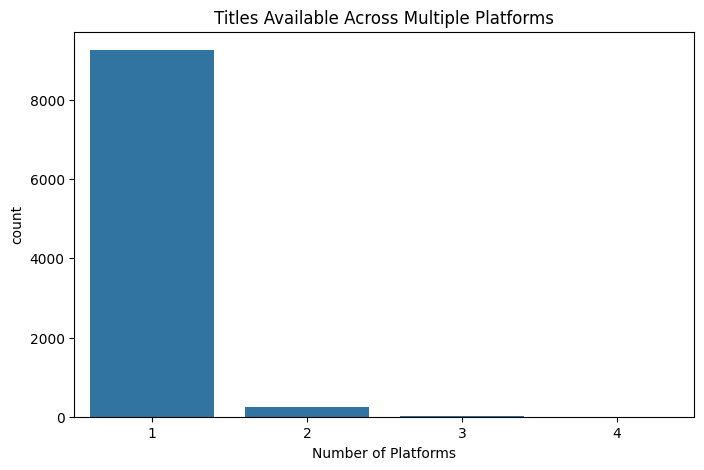

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='Total_Platforms', data=df)

plt.title('Titles Available Across Multiple Platforms')

plt.xlabel('Number of Platforms')

plt.show()

Top Rated Movies

In [ ]:
top_movies = df.sort_values(
    by='Rotten Tomatoes',
    ascending=False
)

top_movies[['Title', 'Rotten Tomatoes']].head(10)

,Title,Rotten Tomatoes
0,The Irishman,98
1,Dangal,97
8615,Mary Poppins,96
2,David Attenborough: A Life on Our Planet,95
5,To All the Boys I've Loved Before,94
3695,The Dark Knight,94
4,Roma,94
3,Lagaan: Once Upon a Time in India,94
4704,Tumbbad,93
4703,Fight Club,93


Visualizing top rated movies

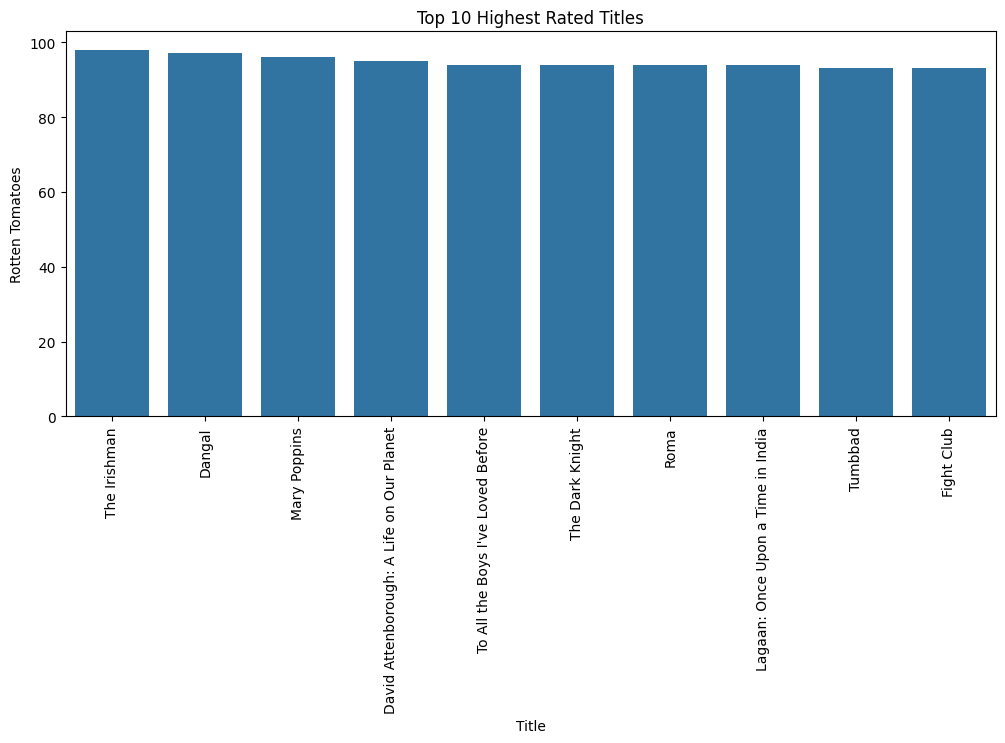

In [ ]:
top10 = top_movies.head(10)

plt.figure(figsize=(12,5))

sns.barplot(
    x='Title',
    y='Rotten Tomatoes',
    data=top10
)

plt.xticks(rotation=90)

plt.title('Top 10 Highest Rated Titles')

plt.show()

Expoting Cleaned Data

In [ ]:
df.to_csv('cleaned_ott_dataset.csv', index=False)

Downloading the cleaned Dataset

In [ ]:
from google.colab import files

files.download('cleaned_ott_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Analysis Per Platform

Highest Rated Content Per Platfrom

**Netflix**

In [ ]:
netflix_top = df[df['Netflix']==1].sort_values(
    by='Rotten Tomatoes',
    ascending=False
)

netflix_top[['Title', 'Rotten Tomatoes']].head(10)

,Title,Rotten Tomatoes
0,The Irishman,98
1,Dangal,97
2,David Attenborough: A Life on Our Planet,95
4,Roma,94
3,Lagaan: Once Upon a Time in India,94
5,To All the Boys I've Loved Before,94
6,The Social Dilemma,93
7,Okja,92
11,Jim & Andy: The Great Beyond- Featuring a Very...,92
10,Article 15,92


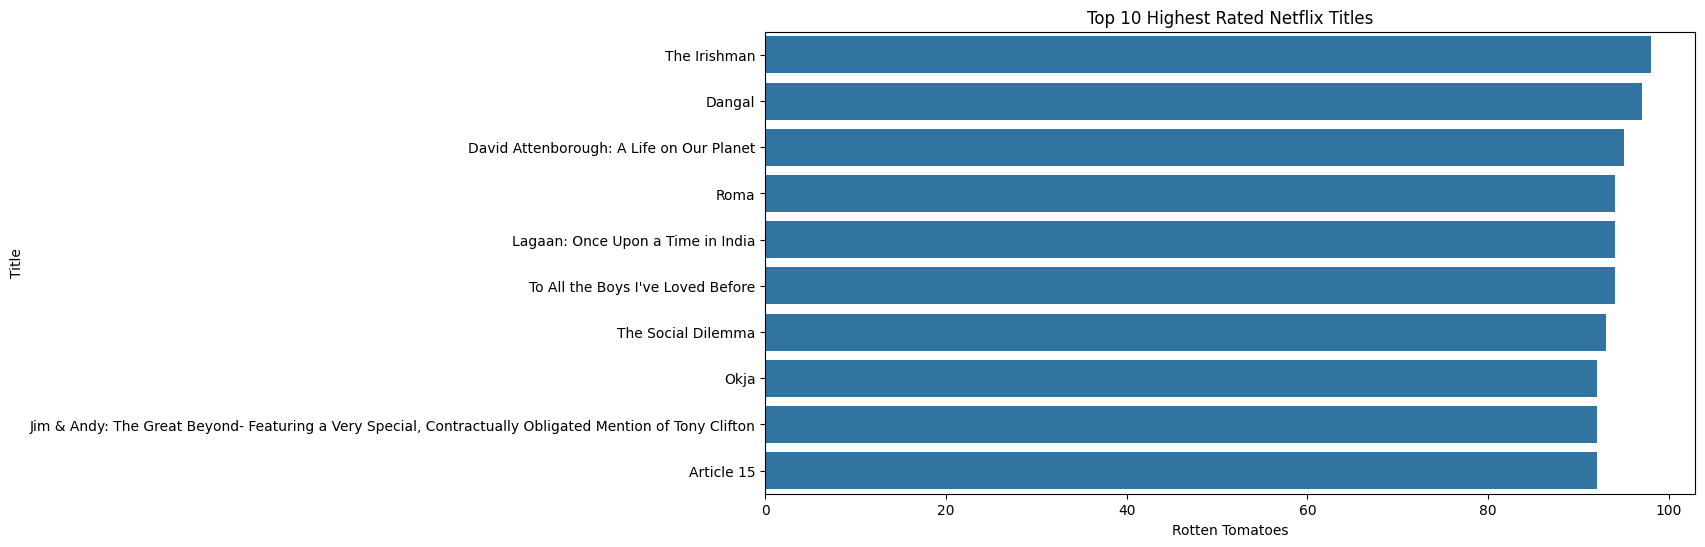

In [ ]:
top10_netflix = netflix_top.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Rotten Tomatoes',
    y='Title',
    data=top10_netflix
)

plt.title('Top 10 Highest Rated Netflix Titles')

plt.show()

**HULU**

In [ ]:
hulu_top = df[df['Hulu']==1].sort_values(
    by='Rotten Tomatoes',
    ascending=False
)

hulu_top[['Title', 'Rotten Tomatoes']].head(10)

,Title,Rotten Tomatoes
3695,The Dark Knight,94
3696,Minding the Gap,90
3698,Batman Begins,88
3697,Parasite,88
3700,Catch Me If You Can,87
3701,The Terminator,87
3699,Gone Girl,87
3703,Prisoners,86
3702,Arrival,86
3705,Shrek,85


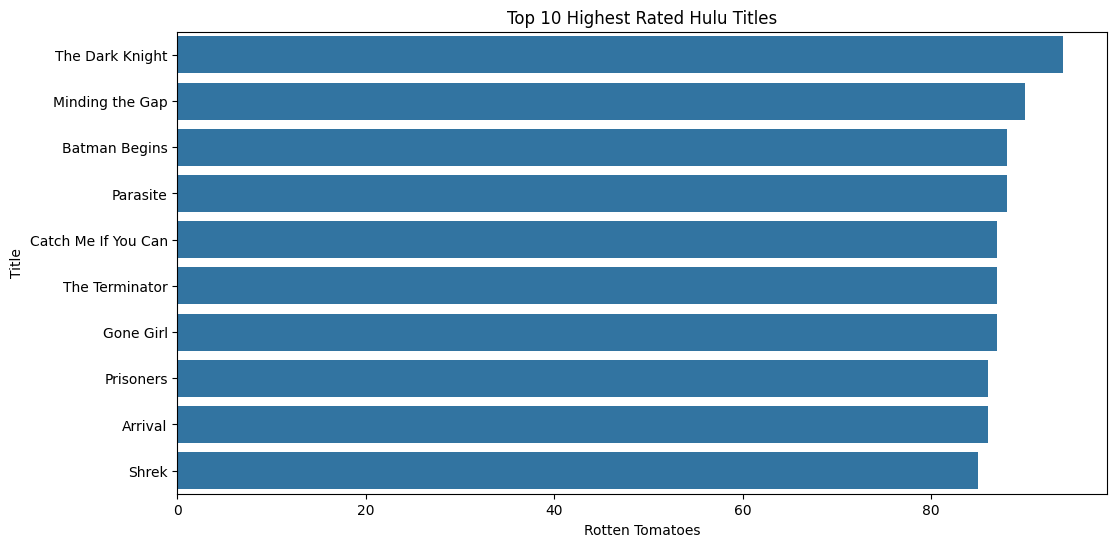

In [ ]:
top10_hulu = hulu_top.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Rotten Tomatoes',
    y='Title',
    data=top10_hulu
)

plt.title('Top 10 Highest Rated Hulu Titles')

plt.show()

**Prime Video**

In [ ]:
prime_video_top = df[df['Prime Video']==1].sort_values(
    by='Rotten Tomatoes',
    ascending=False
)

prime_video_top[['Title', 'Rotten Tomatoes']].head(10)

,Title,Rotten Tomatoes
4703,Fight Club,93
4704,Tumbbad,93
4705,Gully Boy,91
4706,Chak De! India,90
4708,The Report,89
4707,Honey Boy,89
4710,Borat Subsequent Moviefilm,88
4711,Raazi,88
4709,Alien,88
4713,Beautiful Boy,87


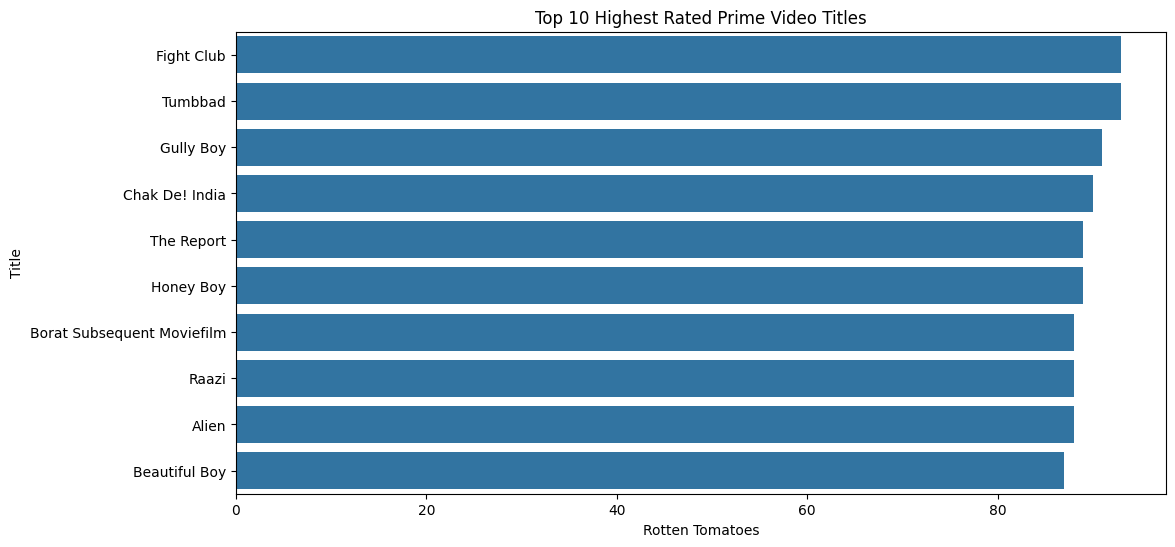

In [ ]:
top10_prime_video = prime_video_top.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Rotten Tomatoes',
    y='Title',
    data=top10_prime_video
)

plt.title('Top 10 Highest Rated Prime Video Titles')

plt.show()

**Disney+**

In [ ]:
disney_top = df[df['Disney+']==1].sort_values(
    by='Rotten Tomatoes',
    ascending=False
)

disney_top[['Title', 'Rotten Tomatoes']].head(10)

,Title,Rotten Tomatoes
8615,Mary Poppins,96
8617,Avengers: Infinity War,90
8616,Avengers: Endgame,90
8622,The Lion King,89
8619,Star Wars: The Empire Strikes Back,89
8618,Star Wars: A New Hope,89
8620,Soul,89
8621,Guardians of the Galaxy,89
8624,The Avengers,88
8623,WALL·E,88


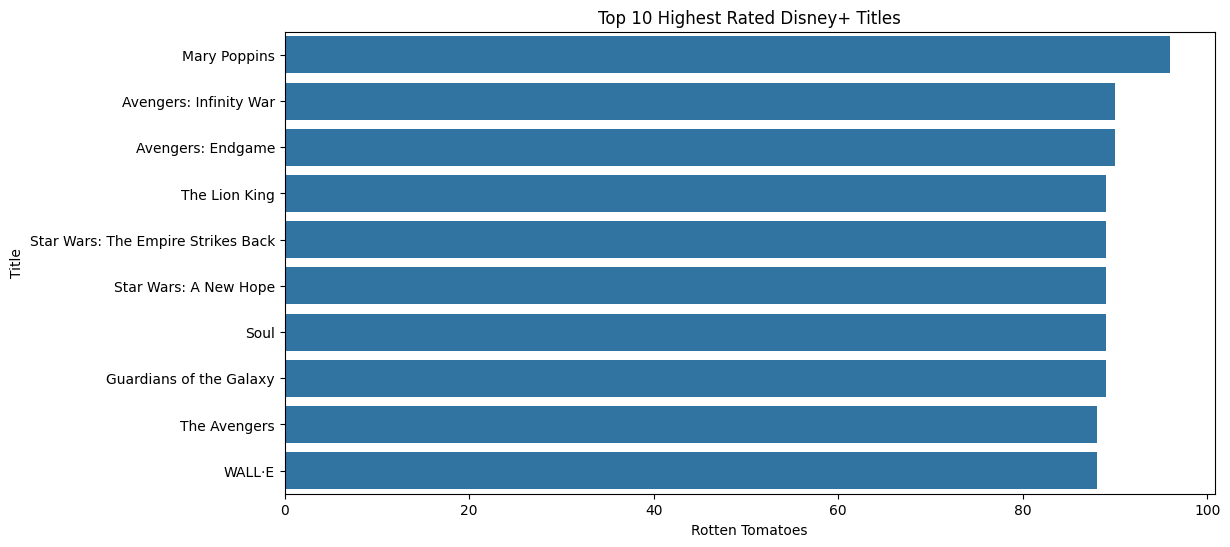

In [ ]:
top10_disney = disney_top.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Rotten Tomatoes',
    y='Title',
    data=top10_disney
)

plt.title('Top 10 Highest Rated Disney+ Titles')

plt.show()

**Year-wise Growth Per Platform**

**Netflix**

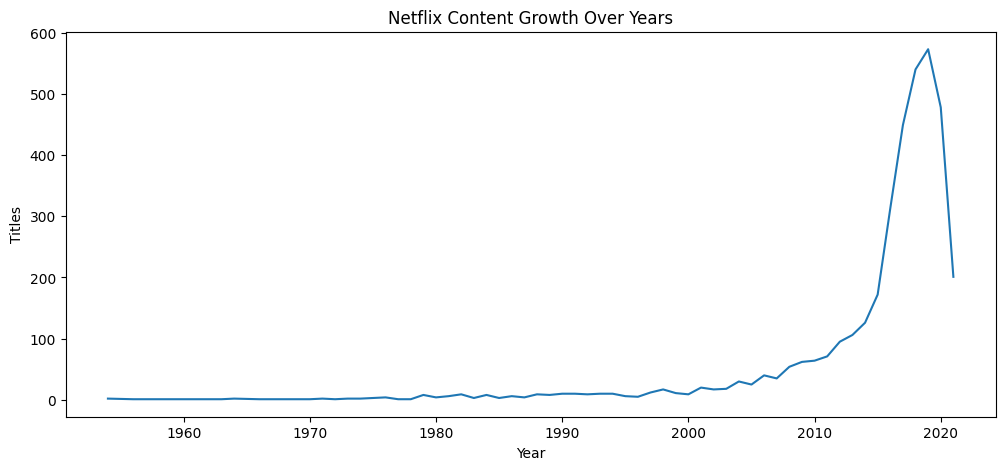

In [ ]:
netflix_yearly = df[df['Netflix']==1]['Year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

netflix_yearly.plot()

plt.title('Netflix Content Growth Over Years')

plt.xlabel('Year')
plt.ylabel('Titles')

plt.show()

**HULU**

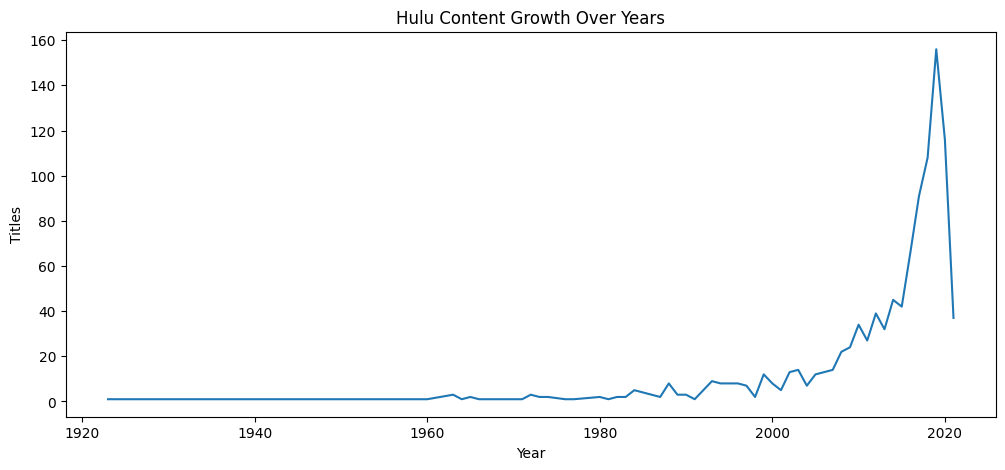

In [ ]:
hulu_yearly = df[df['Hulu']==1]['Year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

hulu_yearly.plot()

plt.title('Hulu Content Growth Over Years')

plt.xlabel('Year')
plt.ylabel('Titles')

plt.show()

**Prime Video**

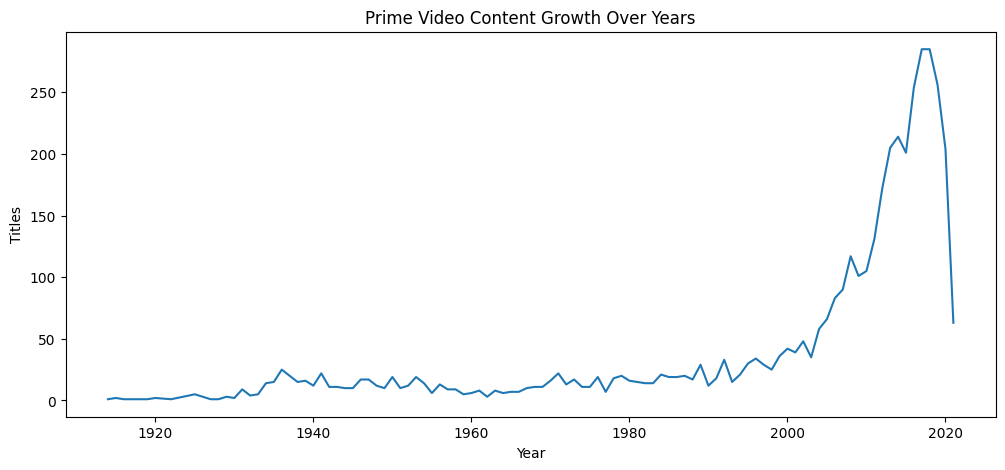

In [ ]:
prime_video_yearly = df[df['Prime Video']==1]['Year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

prime_video_yearly.plot()

plt.title('Prime Video Content Growth Over Years')

plt.xlabel('Year')
plt.ylabel('Titles')

plt.show()

**Disney+**

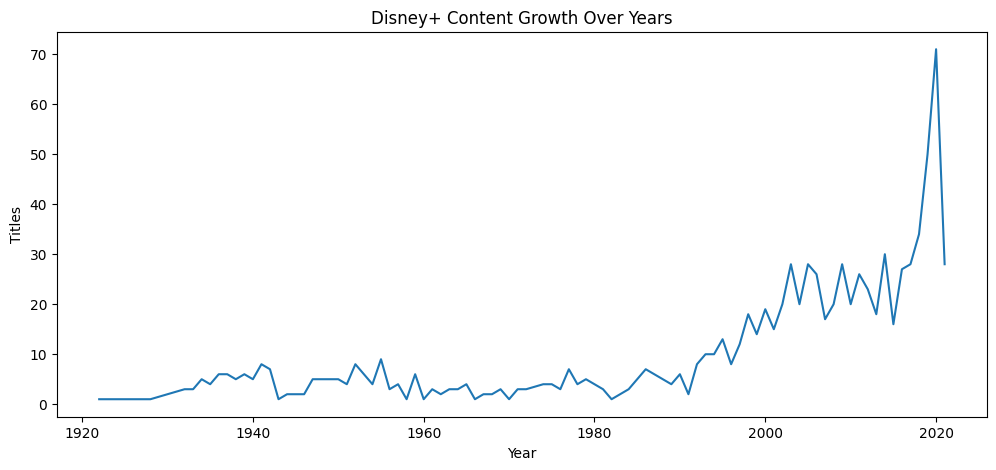

In [ ]:
disney_yearly = df[df['Disney+']==1]['Year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

disney_yearly.plot()

plt.title('Disney+ Content Growth Over Years')

plt.xlabel('Year')
plt.ylabel('Titles')

plt.show()

**Best Platform Based on Average Ratings**

In [ ]:
avg_ratings = pd.DataFrame({
    'Platform': ['Netflix', 'Hulu', 'Prime Video', 'Disney+'],
    'Average Rating': [
        df[df['Netflix']==1]['Rotten Tomatoes'].mean(),
        df[df['Hulu']==1]['Rotten Tomatoes'].mean(),
        df[df['Prime Video']==1]['Rotten Tomatoes'].mean(),
        df[df['Disney+']==1]['Rotten Tomatoes'].mean()
    ]
})

avg_ratings

,Platform,Average Rating
0,Netflix,54.344790
1,Hulu,60.397326
2,Prime Video,50.398736
3,Disney+,58.312364


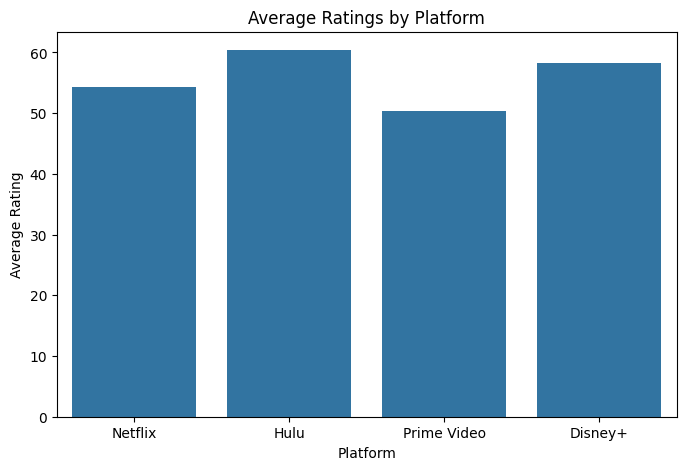

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Platform',
    y='Average Rating',
    data=avg_ratings
)

plt.title('Average Ratings by Platform')

plt.show()

**Correlation Haatmap**

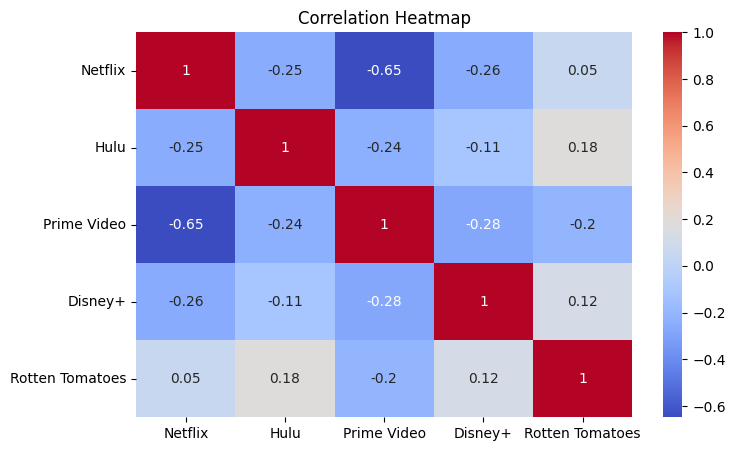

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Netflix', 'Hulu', 'Prime Video', 'Disney+', 'Rotten Tomatoes']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

**Top Years with Highest Rated Content**

In [ ]:
year_rating = df.groupby('Year')['Rotten Tomatoes'].mean()

year_rating.sort_values(ascending=False).head(10)

,Rotten Tomatoes
Year,
1919,62.000000
1923,60.000000
1993,59.659091
1990,59.516129
1992,58.961538
2002,58.904255
2004,58.761468
1974,58.421053
1997,58.403509


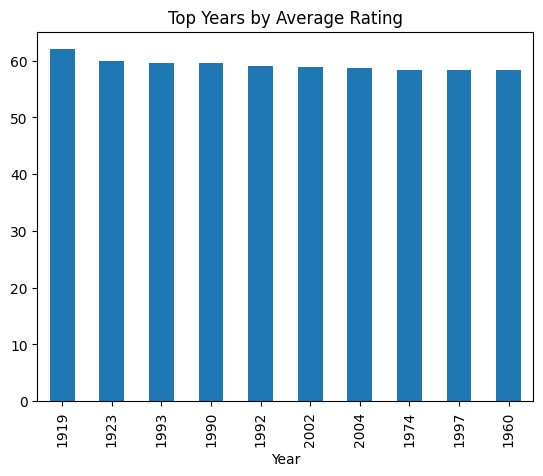

In [ ]:
year_rating.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title('Top Years by Average Rating')

plt.show()

**Content Availability Comparison**

In [ ]:
exclusive_titles = df[df['Total_Platforms'] == 1]

exclusive_titles.shape

(9262, 11)

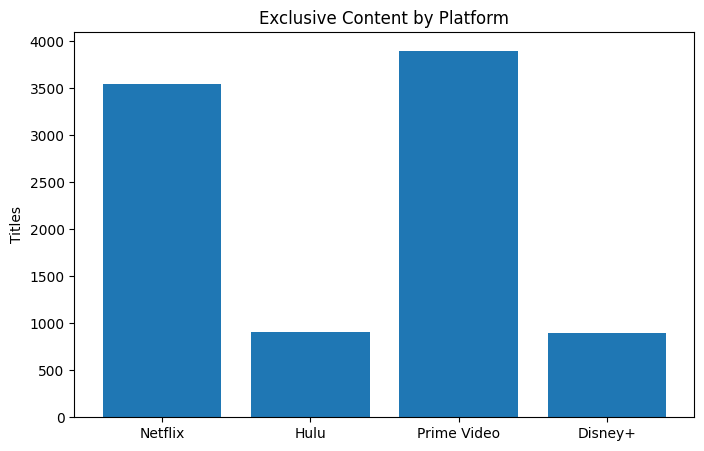

In [ ]:
exclusive_counts = {
    'Netflix': len(df[
        (df['Netflix']==1) &
        (df['Total_Platforms']==1)
    ]),

    'Hulu': len(df[
        (df['Hulu']==1) &
        (df['Total_Platforms']==1)
    ]),

    'Prime Video': len(df[
        (df['Prime Video']==1) &
        (df['Total_Platforms']==1)
    ]),

    'Disney+': len(df[
        (df['Disney+']==1) &
        (df['Total_Platforms']==1)
    ])
}

plt.figure(figsize=(8,5))

plt.bar(
    exclusive_counts.keys(),
    exclusive_counts.values()
)

plt.title('Exclusive Content by Platform')

plt.ylabel('Titles')

plt.show()

**Distribution of Ratings by Platform**

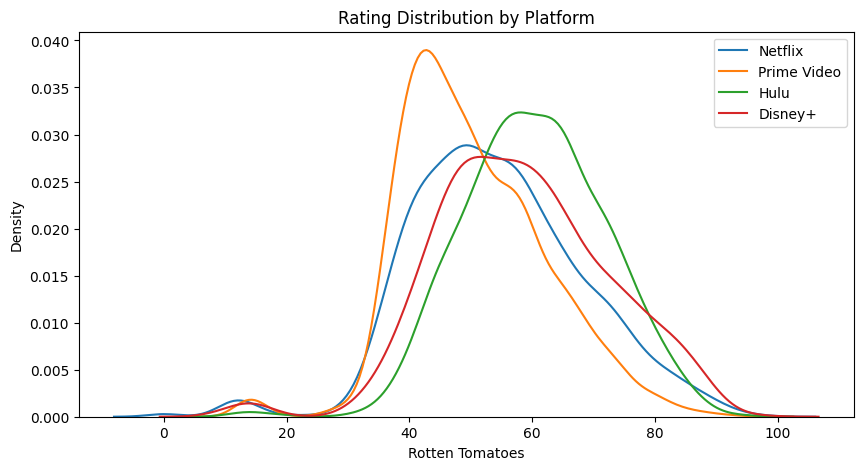

In [ ]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    df[df['Netflix']==1]['Rotten Tomatoes'],
    label='Netflix'
)

sns.kdeplot(
    df[df['Prime Video']==1]['Rotten Tomatoes'],
    label='Prime Video'
)

sns.kdeplot(
    df[df['Hulu']==1]['Rotten Tomatoes'],
    label='Hulu'
)

sns.kdeplot(
    df[df['Disney+']==1]['Rotten Tomatoes'],
    label='Disney+'
)

plt.title('Rating Distribution by Platform')

plt.legend()

plt.show()

Outlier Detection

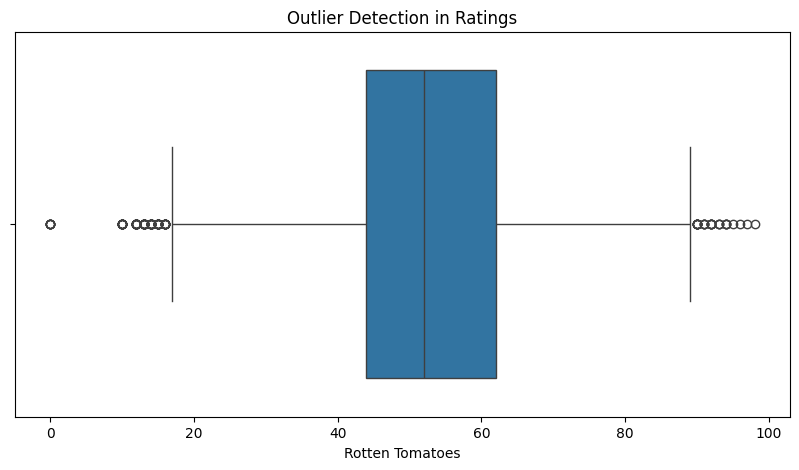

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['Rotten Tomatoes']
)

plt.title('Outlier Detection in Ratings')

plt.show()

Creating Rating Category

In [ ]:
def rating_category(x):
    if x >= 90:
        return 'Excellent'
    elif x >= 75:
        return 'Good'
    elif x >= 50:
        return 'Average'
    else:
        return 'Poor'

df['Rating_Category'] = df['Rotten Tomatoes'].apply(rating_category)

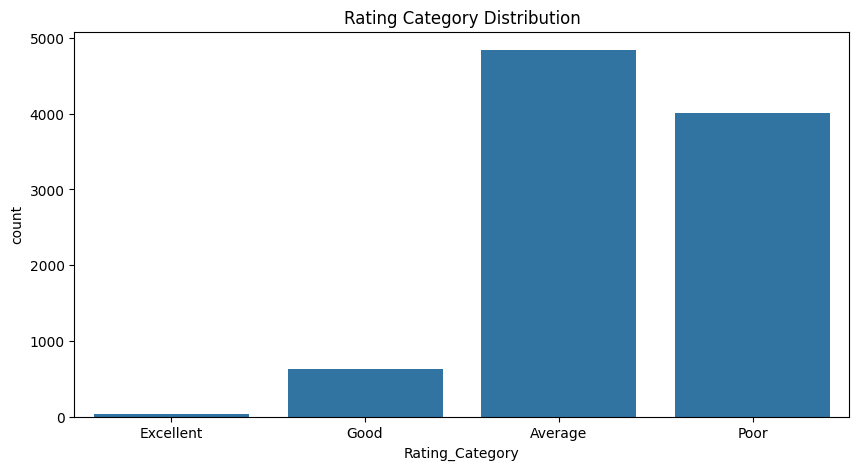

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Rating_Category'
)

plt.title('Rating Category Distribution')

plt.show()

Analyzing Platform Dominance

In [ ]:
excellent_movies = df[df['Rating_Category']=='Excellent']

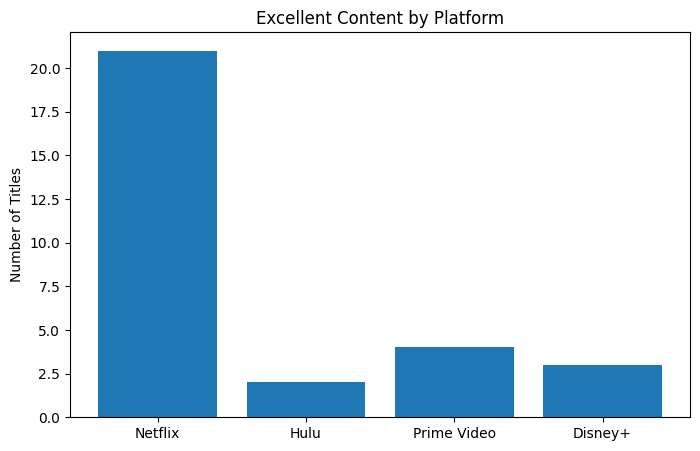

In [ ]:
excellent_counts = {
    'Netflix': len(excellent_movies[excellent_movies['Netflix']==1]),
    'Hulu': len(excellent_movies[excellent_movies['Hulu']==1]),
    'Prime Video': len(excellent_movies[excellent_movies['Prime Video']==1]),
    'Disney+': len(excellent_movies[excellent_movies['Disney+']==1])
}

plt.figure(figsize=(8,5))

plt.bar(
    excellent_counts.keys(),
    excellent_counts.values()
)

plt.title('Excellent Content by Platform')

plt.ylabel('Number of Titles')

plt.show()

Interactive Visuals in Colab

In [ ]:
import plotly.express as px

fig = px.bar(
    avg_ratings,
    x='Platform',
    y='Average Rating',
    title='Average Ratings by Platform'
)

fig.show()

Decade-wise Content Trend

Addign the 'Decade' Column

In [ ]:
df['Decade'] = (df['Year']//10)*10

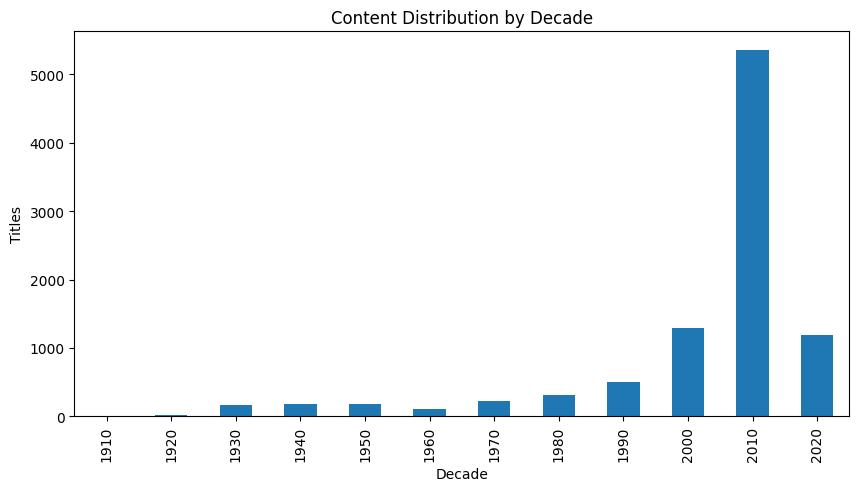

In [ ]:
decade_counts = df['Decade'].value_counts().sort_index()

plt.figure(figsize=(10,5))

decade_counts.plot(kind='bar')

plt.title('Content Distribution by Decade')

plt.xlabel('Decade')

plt.ylabel('Titles')

plt.show()